# Example usage of the ofset free koopman MPC

In [833]:
import sys
import os
import numpy as np
#import pandas as pd
import joblib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
from sklearn.preprocessing import StandardScaler

from neuromancer.system import Node, System
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer. modules import blocks

# Add 'src' to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
src_path = os.path.join(project_root, 'src')
sys.path.append(src_path)

import models
import helper
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading a Dataset

In [834]:
# Load identification data from ../ident_data/ (.mat files)
# Outputs: T2, T4 only. Inputs: u2, u3 only.
from scipy.io import loadmat

data_path = '../ident_data/'

experiment_start = 0
experiment_end = 12  # inclusive; adjust to match available ident_data runs


def trim_to_divisible(arr, divisor=80):
    """Trim array from the rear to make length divisible by divisor"""
    length = len(arr)
    remainder = length % divisor
    if remainder != 0:
        return arr[:length - remainder]
    return arr


nsteps_training = 60  # Must match nsteps used in model training
experiments = []

for exp_num in range(experiment_start, experiment_end + 1):
    T2_data = loadmat(data_path + f'T2_ident_{exp_num}.mat')['T2']
    T4_data = loadmat(data_path + f'T4_ident_{exp_num}.mat')['T4']
    u2_data = loadmat(data_path + f'u2_ident_{exp_num}.mat')['u2'].reshape(-1, 1)
    u3_data = loadmat(data_path + f'u3_ident_{exp_num}.mat')['u3'].reshape(-1, 1)

    DOWNSAMPLE_FACTOR = 5

    length = min(len(T2_data), len(T4_data), len(u2_data), len(u3_data))
    divisor = nsteps_training * DOWNSAMPLE_FACTOR
    T2_data = trim_to_divisible(T2_data[:length], divisor=divisor)
    T4_data = trim_to_divisible(T4_data[:length], divisor=divisor)
    u2_data = trim_to_divisible(u2_data[:length], divisor=divisor)
    u3_data = trim_to_divisible(u3_data[:length], divisor=divisor)

    
    Y = np.concatenate(
        [T2_data[::DOWNSAMPLE_FACTOR], T4_data[::DOWNSAMPLE_FACTOR]],
        axis=1,
    )
    U = np.concatenate(
        [u2_data[::DOWNSAMPLE_FACTOR], u3_data[::DOWNSAMPLE_FACTOR]],
        axis=1,
    )

    Y_clean = trim_to_divisible(Y, divisor=nsteps_training)
    U_clean = trim_to_divisible(U, divisor=nsteps_training)

    if len(Y_clean) == 0 or len(U_clean) == 0:
        print(f"  Skipping experiment {exp_num}: No valid data")
        continue

    assert len(Y_clean) % nsteps_training == 0, (
        f"Exp {exp_num}: length {len(Y_clean)} not divisible by {nsteps_training}"
    )

    if len(Y_clean) < len(Y):
        print(f"  Experiment {exp_num}: Trimmed from {len(Y)} to {len(Y_clean)} samples")

    experiments.append({
        'Y': Y_clean,
        'U': U_clean,
        'exp_num': exp_num,
        'source': 'ident_data',
    })

print(f"Loaded {len(experiments)} experiments from {data_path}")

# Train on ident runs with exp_num <= 4; hold out exp_num == 5 for test
train_experiments = [
    exp for exp in experiments
    if exp['source'] == 'ident_data' and exp['exp_num'] <= 6 or (exp['exp_num'] > 7 and exp['exp_num'] < 12)
]
test_experiments = [
    exp for exp in experiments
    if exp['source'] == 'ident_data' and exp['exp_num'] == 7 or exp['exp_num'] == 12
]

if len(train_experiments) == 0:
    raise ValueError(
        "No valid training experiments found! All experiments may have been filtered out."
    )

train = {
    'Y': np.vstack([exp['Y'] for exp in train_experiments]),
    'U': np.vstack([exp['U'] for exp in train_experiments]),
}

if len(test_experiments) == 0:
    print("Warning: No valid test experiments found. Using last 20% of training data for testing.")
    split_idx = int(len(train['Y']) * 0.8)
    split_idx = (split_idx // nsteps_training) * nsteps_training

    test = {
        'Y': train['Y'][split_idx:],
        'U': train['U'][split_idx:],
    }
    train = {
        'Y': train['Y'][:split_idx],
        'U': train['U'][:split_idx],
    }
else:
    test = {
        'Y': np.vstack([exp['Y'] for exp in test_experiments]),
        'U': np.vstack([exp['U'] for exp in test_experiments]),
    }

train_list = [{'Y': exp['Y'], 'U': exp['U']} for exp in train_experiments]
test_list = [{'Y': exp['Y'], 'U': exp['U']} for exp in test_experiments]

print("\n" + "=" * 70)
print("SUMMARY: ident_data loaded successfully (T2, T4 | u2, u3)")
print("=" * 70)
print(f"ident_data: experiments {experiment_start} to {experiment_end}")
print(f"Training experiments: {[exp['exp_num'] for exp in train_experiments]}")
print(f"Test experiments: {[exp['exp_num'] for exp in test_experiments]}")
print(f"Training samples (combined): {len(train['Y'])}  (ny=2, nu=2)")
print(f"Test samples (combined): {len(test['Y'])}")
print(f"Individual experiment lengths: {[len(exp['Y']) for exp in experiments]}")
print("=" * 70)

# Dict views for plotting / legacy cells (2 outputs, 2 inputs)
T2_train = {'T2': train['Y'][:, :1]}
T4_train = {'T4': train['Y'][:, 1:2]}
u2_train = {'u2': train['U'][:, :1]}
u3_train = {'u3': train['U'][:, 1:2]}

T2_test = {'T2': test['Y'][:, :1]}
T4_test = {'T4': test['Y'][:, 1:2]}
u2_test = {'u2': test['U'][:, :1]}
u3_test = {'u3': test['U'][:, 1:2]}


Loaded 13 experiments from ../ident_data/

SUMMARY: ident_data loaded successfully (T2, T4 | u2, u3)
ident_data: experiments 0 to 12
Training experiments: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11]
Test experiments: [7, 12]
Training samples (combined): 6600  (ny=2, nu=2)
Test samples (combined): 1200
Individual experiment lengths: [600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600]


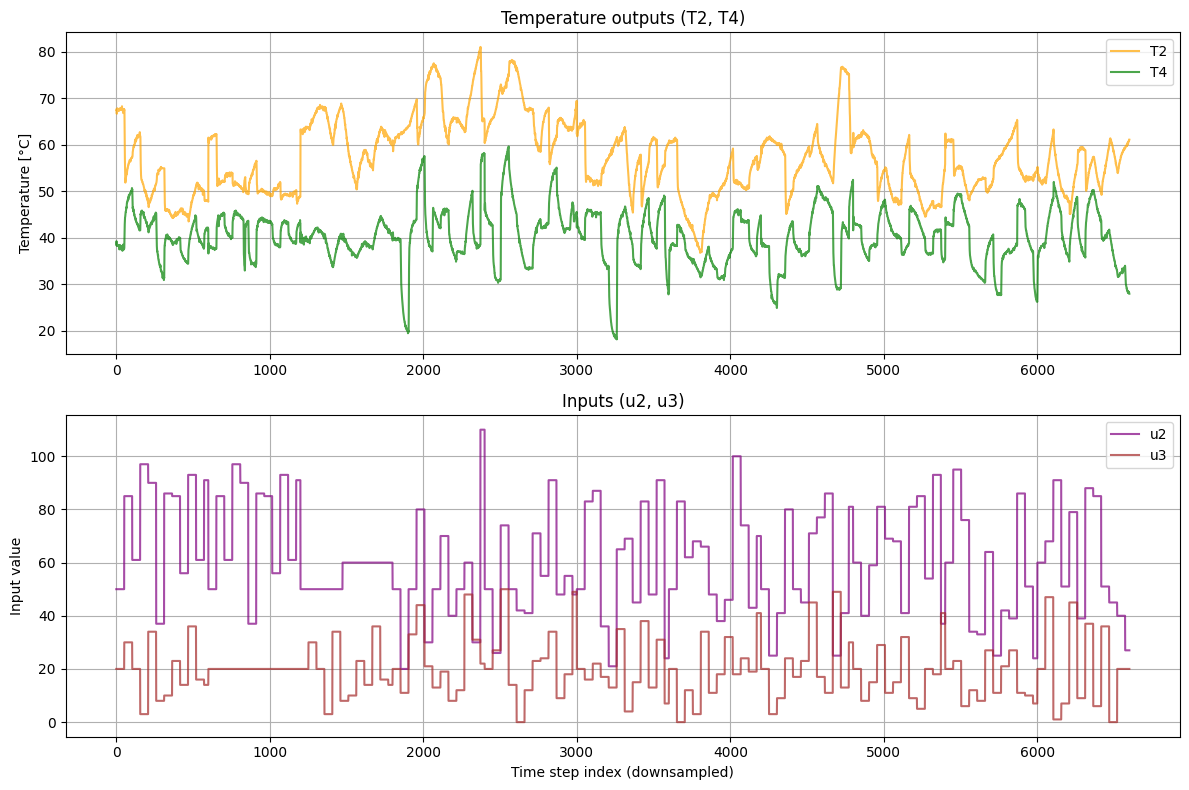

In [835]:
# Extract data for plotting (T2, T4 and u2, u3 only)
T2_data = T2_train['T2'].flatten()
T4_data = T4_train['T4'].flatten()

u2_data = u2_train['u2'].flatten()
u3_data = u3_train['u3'].flatten()

part = min(7840, len(T2_data))

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(T2_data[:part], label='T2', alpha=0.7, color='orange')
plt.plot(T4_data[:part], label='T4', alpha=0.7, color='green')
plt.title("Temperature outputs (T2, T4)")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(u2_data[:part], label='u2', alpha=0.7, color='purple')
plt.plot(u3_data[:part], label='u3', alpha=0.7, color='brown')
plt.title("Inputs (u2, u3)")
plt.xlabel("Time step index (downsampled)")
plt.ylabel("Input value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Preparing data for training koopman models

In [836]:
def get_data(train_sim, dev_sim, test_sim, nsteps, bs, scaler, scalerU):
    
    ny = train_sim['Y'].shape[1]
    nu = train_sim['U'].shape[1]
    
    nsim = train_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps

    trainX = scaler.transform(train_sim['Y'][:length])
    trainX = trainX.reshape(nbatch, nsteps, ny)
    trainX = torch.tensor(trainX, dtype=torch.float32)
    trainU = scalerU.transform(train_sim['U'][:length])
    trainU = trainU.reshape(nbatch, nsteps, nu)
    trainU = torch.tensor(trainU, dtype=torch.float32)
    train_data = DictDataset({'Y': trainX, 'Y0': trainX[:, 0:1, :],
                              'U': trainU}, name='train')
    train_loader = DataLoader(train_data, batch_size=bs,
                              collate_fn=train_data.collate_fn, shuffle=True)
    
    nsim = dev_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps
    
    devX = scaler.transform(dev_sim['Y'][:length])
    devX = devX.reshape(nbatch, nsteps, ny)
    devX = torch.tensor(devX, dtype=torch.float32)
    devU = scalerU.transform(dev_sim['U'][:length])
    devU = devU[:length].reshape(nbatch, nsteps, nu)
    devU = torch.tensor(devU, dtype=torch.float32)
    dev_data = DictDataset({'Y': devX, 'Y0': devX[:, 0:1, :],
                            'U': devU}, name='dev')
    dev_loader = DataLoader(dev_data, batch_size=bs,
                            collate_fn=dev_data.collate_fn, shuffle=True)

    nsim = test_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps
    
    testX = scaler.transform(test_sim['Y'][:length])
    testX = testX.reshape(1, nbatch*nsteps, ny)
    testX = torch.tensor(testX, dtype=torch.float32)
    testU = scalerU.transform(test_sim['U'][:length])
    testU = testU.reshape(1, nbatch*nsteps, nu)
    testU = torch.tensor(testU, dtype=torch.float32)
    test_data = {'Y': testX, 'Y0': testX[:, 0:1, :],
                 'U': testU}
    
    trainX = scaler.transform(train_sim['Y'][:length])
    trainX = trainX.reshape(1, nbatch*nsteps, ny)
    trainX = torch.tensor(trainX, dtype=torch.float32)
    trainU = scalerU.transform(train_sim['U'][:length])
    trainU = trainU.reshape(1, nbatch*nsteps, nu)
    trainU = torch.tensor(trainU, dtype=torch.float32)
    train_data_forC = {'Y': trainX, 'Y0': trainX[:, 0:1, :],
                 'U': trainU}

    return train_loader, dev_loader, test_data, train_data_forC

In [837]:
nsteps = 60   # number of prediction horizon steps in the loss function
bs = 80      # minibatching batch size

In [838]:
scaler = joblib.load('../data/scaler.pkl')
scalerU = joblib.load('../data/scalerU.pkl')


In [839]:
train_loader, dev_loader, test_data, train_data = get_data(train, test, test, nsteps, bs, scaler, scalerU)

## Creating the model


In [840]:
# model parameters
nz = 16
ny = train['Y'].shape[1]
nu = train['U'].shape[1]

cons = 1
layers = [4*cons,8*cons,16*cons]
layers_dec  = [16*cons,8*cons,4*cons]

matrix_C = True

In [841]:
# instantiate output encoder neural net f_y
f_y = blocks.MLP(
    ny,
    nz,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ReLU,
    hsizes=layers,
)
# initial condition encoder
encode_Y0 = Node(f_y, ['Y0'], ['x'], name='encoder_Y0')
# observed trajectory encoder
encode_Y = Node(f_y, ['Y'], ['x_latent'], name='encoder_Y')

In [842]:
# instantiate input encoder net f_u, representing the B matrix in the linear system
f_u = torch.nn.Linear(nu, nz, bias=False)
# initial condition encoder
encode_U = Node(f_u, ['U'], ['u_latent'], name='encoder_U')

In [843]:
# instantiate state decoder neural net f_y_inv
if not matrix_C:
    f_y_inv = blocks.MLP(nz, ny, bias=True,
                    linear_map=torch.nn.Linear,
                    nonlin=torch.nn.ELU,
                    hsizes=layers_dec)
elif matrix_C:
    f_y_inv = torch.nn.Linear(nz, ny, bias=False)
else:
    raise ValueError('matrix_C must be boolean')

# predicted trajectory decoder
decode_y = Node(f_y_inv, ['x'], ['yhat'], name='decoder_y')

In [844]:
# representing matrix A in the linear system
K = torch.nn.Linear(nz, nz, bias=False)

In [845]:
# symbolic Koopman model with control inputs
Koopman = Node(helper.PredictionWControl(K), ['x', 'u_latent'], ['x'], name='K')

# latent Koopmann rollout
dynamics_model = System([Koopman], name='Koopman', nsteps=nsteps)

In [846]:
# put all nodes of the Koopman model together in a list of nodes
nodes = [encode_Y0, encode_Y, encode_U, dynamics_model, decode_y]

### Define Koopman system identification loss function terms

In [847]:
# variables
Y = variable("Y")  # observed
yhat = variable('yhat')  # predicted output
x_latent = variable('x_latent')  # encoded output trajectory in the latent space
u_latent = variable('u_latent')  # encoded input trajectory in the latent space
x = variable('x')  # Koopman latent space trajectory

xu_latent = x_latent + u_latent  # latent state trajectory

# output trajectory tracking loss
y_loss = 10. * (yhat[:, 1:-1, :] == Y[:, 1:, :]) ^ 2
y_loss.name = "y_loss"

# one-step tracking loss
onestep_loss = 1.*(yhat[:, 1, :] == Y[:, 1, :])^2
onestep_loss.name = "onestep_loss"

# reconstruction loss
reconstruction_loss = 1.*(yhat[:, 0, :] == Y[:, 0, :])^2
reconstruction_loss.name = "reconstruction_loss"

# latent trajectory tracking loss
x_loss = 1. * (x[:, 1:-1, :] == xu_latent[:, 1:, :]) ^ 2
x_loss.name = "x_loss"

### Construct System learning problem

In [848]:
# aggregate list of objective terms and constraints
objectives = [y_loss, x_loss, onestep_loss, reconstruction_loss]

# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints=[])

# construct constrained optimization problem
problem = Problem(nodes, loss)

In [849]:
problem.nodes

ModuleList(
  (0): encoder_Y0(Y0) -> x
  (1): encoder_Y(Y) -> x_latent
  (2): encoder_U(U) -> u_latent
  (3): System(
    (nodes): ModuleList(
      (0): K(x, u_latent) -> x
    )
  )
  (4): decoder_y(x) -> yhat
)

### Solve the problem

In [850]:
from neuromancer.trainer import Callback

class PrintCallback(Callback):
    def end_eval(self, trainer, output):
        if trainer.current_epoch % trainer.epoch_verbose == 0:
            train_loss = output.get('mean_train_loss', output.get('train_loss', 'N/A'))
            dev_loss = output.get('mean_dev_loss', output.get('dev_loss', 'N/A'))
            print(f"epoch: {trainer.current_epoch}  "
                  f"train_loss: {train_loss}  "
                  f"dev_loss: {dev_loss}")

optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)

trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_data,
    optimizer,
    callback=PrintCallback(),
    patience=300,
    warmup=100,
    epochs=4000,
    eval_metric="dev_loss",
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="dev_loss",
)


In [851]:
# train

best_model = trainer.train()
problem.load_state_dict(best_model)


epoch: 0  train_loss: 15.701786041259766
epoch: 0  train_loss: 15.701786041259766  dev_loss: 16.34398651123047
epoch: 1  train_loss: 14.634878158569336
epoch: 1  train_loss: 14.634878158569336  dev_loss: 15.662215232849121
epoch: 2  train_loss: 14.754349708557129
epoch: 2  train_loss: 14.754349708557129  dev_loss: 15.031736373901367
epoch: 3  train_loss: 14.683075904846191
epoch: 3  train_loss: 14.683075904846191  dev_loss: 14.4496488571167
epoch: 4  train_loss: 13.243401527404785
epoch: 4  train_loss: 13.243401527404785  dev_loss: 13.907365798950195
epoch: 5  train_loss: 13.360001564025879
epoch: 5  train_loss: 13.360001564025879  dev_loss: 13.404478073120117
epoch: 6  train_loss: 12.323589324951172
epoch: 6  train_loss: 12.323589324951172  dev_loss: 12.94012451171875
epoch: 7  train_loss: 12.330987930297852
epoch: 7  train_loss: 12.330987930297852  dev_loss: 12.512248992919922
epoch: 8  train_loss: 13.243696212768555
epoch: 8  train_loss: 13.243696212768555  dev_loss: 12.111483573913

<All keys matched successfully>

### Saving model and evaluation of the training

In [852]:
# save model
torch.save(best_model, "../data/model_C_" + str(matrix_C) + ".pth")

# pull matrices
A = K.weight.detach().numpy()
B = f_u.weight.detach().numpy()
if matrix_C:
    C = f_y_inv.weight.detach().numpy()
    
elif not matrix_C:
    # get approximate C matrix from training data
    problem.nodes[3].nsteps = train_data['Y'].shape[1]
    train_outputs = problem.step(train_data)

    Y = train_data['Y'].reshape(-1, ny).detach().numpy()
    Z = train_outputs['x'][:,:-1,:].detach().numpy().reshape(-1, nz)
    rankZ = np.linalg.matrix_rank(Z)
    if rankZ < nz:
        print('Rank deficient Z matrix, can result in bad fitted C matrix!')
    C, residuals, rank, s = np.linalg.lstsq(Z, Y, rcond=None)
    C = C.T

else:
    raise ValueError('matrix_C must be boolean')

In [853]:
from numpy.linalg import matrix_rank

# Compute the controllability matrix
n_states = A.shape[0]
controllability_matrix = np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(n_states)])

# Check the rank of the controllability matrix
controllability_rank = matrix_rank(controllability_matrix)

print(f"Controllability Matrix Rank: {controllability_rank}")
print(f"System is {'controllable' if controllability_rank == n_states else 'not controllable'}")

# Compute the observability matrix
observability_matrix = np.vstack([C @ np.linalg.matrix_power(A, i) for i in range(n_states)])

# Check the rank of the observability matrix
observability_rank = matrix_rank(observability_matrix)

print(f"Observability Matrix Rank: {observability_rank}")
print(f"System is {'observable' if observability_rank == n_states else 'not observable'}")

Controllability Matrix Rank: 16
System is controllable
Observability Matrix Rank: 16
System is observable


In [854]:
# # Evaluate Jacobian for each latent state
# J_all = np.stack([
#     helper.evaluate_jacobian(problem.nodes[4], torch.from_numpy(xi).float())
#     for xi in x_train
# ])

# # Compute mean Jacobian
# C = np.mean(J_all, axis=0)
# print("Mean Jacobian J_mean:\n", C) # mean bias?

In [855]:
np.save('../data/A_C_' + str(matrix_C) + '.npy', A)
np.save('../data/B_C_' + str(matrix_C) + '.npy', B)
np.save('../data/C_C_' + str(matrix_C) + '.npy', C)

In [856]:
# update the rollout length based on the test data
problem.nodes[3].nsteps = test_data['Y'].shape[1]

In [857]:
# do the prediction
test_outputs = problem.step(test_data)

pred_traj = test_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, ny).T
true_traj = test_data['Y'][:, 1:pred_traj.shape[1]+1, ].detach().numpy().reshape(-1, ny).T
input_traj = test_data['U'].detach().numpy().reshape(-1, nu).T
pred_x = test_outputs['x'][:, 1:-1, :].detach().numpy().reshape(-1, nz).T

In [858]:
pred_traj_C = np.dot(C, pred_x)

In [859]:
x_mean = np.mean(pred_x, axis=1, keepdims=True)
x_med = np.median(pred_x, axis=1, keepdims=True)

In [860]:
def get_y_from_x(problem, x: np.ndarray) -> np.ndarray:
    y = problem.nodes[4]({"x": torch.from_numpy(x.T).float()})
    return y["yhat"].detach().numpy().reshape(1, -1)

In [861]:
# J = helper.evaluate_jacobian(
#     problem.nodes[4],
#     torch.from_numpy(x_mean[:,0]).float(),
# )
# # Get all latent states from training data
# x_train = train_outputs['x'].detach().numpy().reshape(-1, nz)

# # Evaluate Jacobian for each latent state
# J_all = np.stack([
#     helper.evaluate_jacobian(problem.nodes[4], torch.from_numpy(xi).float())
#     for xi in x_train
# ])

# bias_all = np.stack([
#     get_y_from_x(problem, xi.reshape(-1,1))
#     for xi in x_train
# ])

# # Compute mean Jacobian
# J_mean = np.mean(J_all, axis=0)
# print("Mean Jacobian J_mean:\n", J_mean) # mean bias?

# bias_mean = np.mean(bias_all, axis=0)
# print("Mean Bias:\n", bias_mean)


# pred_traj_J = np.dot(J_mean, pred_x - x_mean) #+ bias_mean.T

In [862]:
x_lin = np.zeros((nz,1))
J = helper.evaluate_jacobian(
    problem.nodes[4],
    torch.from_numpy(x_lin[:,0]).float(),
)

bias = get_y_from_x(problem, x_lin)
pred_traj_J = np.dot(J, pred_x - x_lin) + bias.T

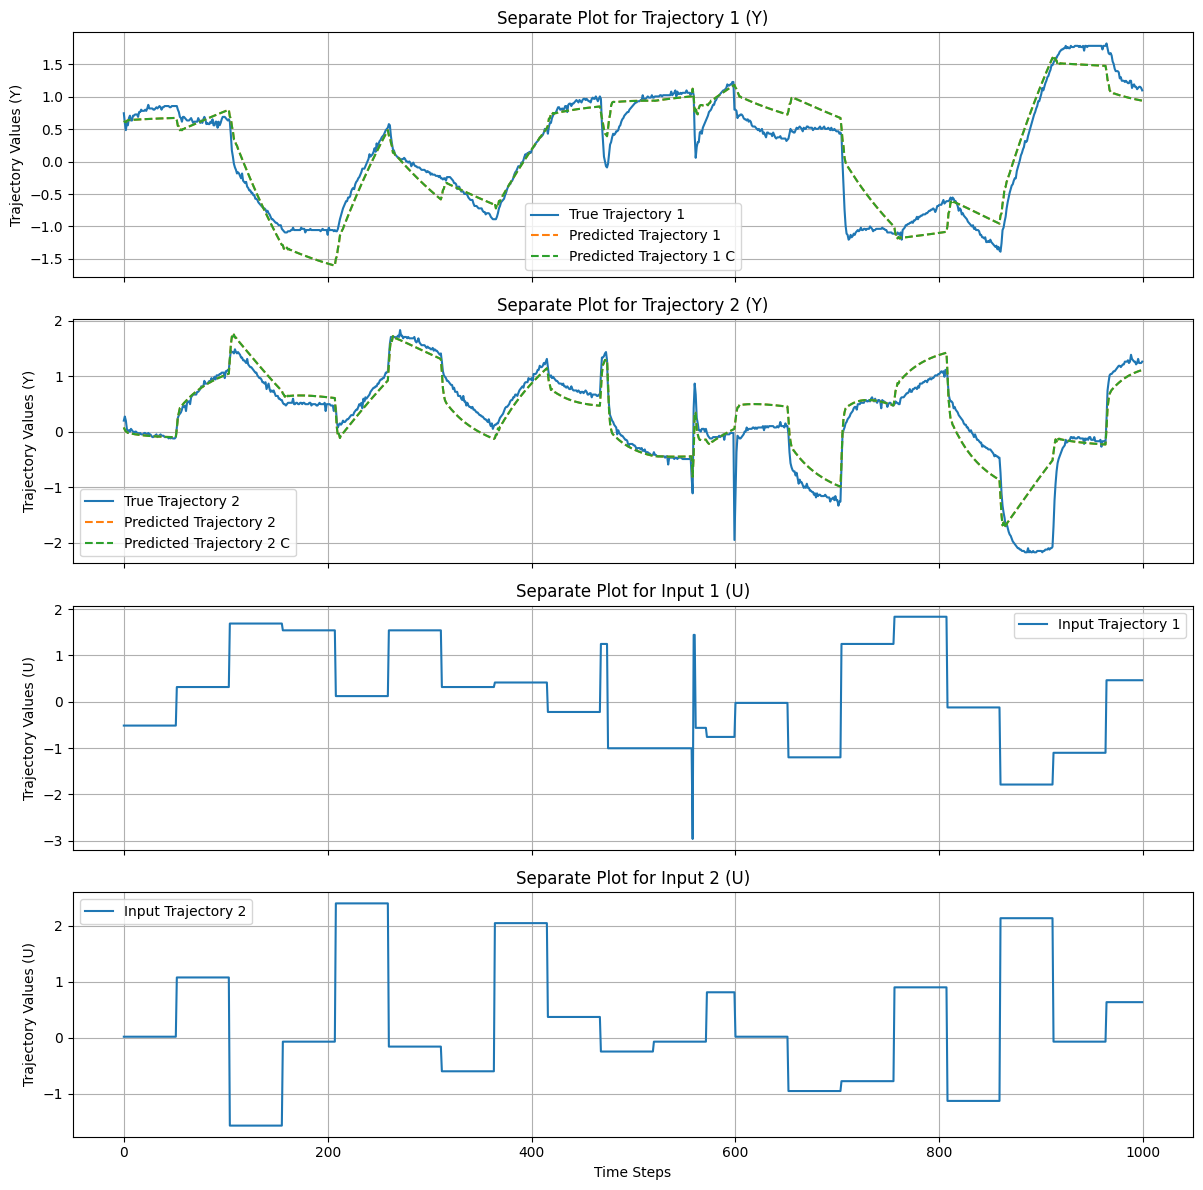

In [863]:
fig, axs = plt.subplots(ny + nu, 1, figsize=(12, 3 * (ny + nu)), sharex=True)

# Separate plots for each vector in Y
for i in range(ny):
    axs[i].plot(true_traj[i,:1000], label=f'True Trajectory {i + 1}', linestyle='-')
    axs[i].plot(pred_traj[i,:1000], label=f'Predicted Trajectory {i + 1}', linestyle='--')
    axs[i].plot(pred_traj_C[i,:1000], label=f'Predicted Trajectory {i + 1} C', linestyle='--')
    #axs[i].plot(pred_traj_J[i], label=f'Predicted Trajectory {i + 1} J', linestyle='--')
    axs[i].set_title(f'Separate Plot for Trajectory {i + 1} (Y)')
    axs[i].legend()
    axs[i].grid()

# Separate plots for each vector in U
for i in range(nu):
    axs[ny + i].plot(input_traj[i,:1000], label=f'Input Trajectory {i + 1}', linestyle='-')
    axs[ny + i].set_title(f'Separate Plot for Input {i + 1} (U)')
    axs[ny + i].legend()
    axs[ny + i].grid()

# Add labels
axs[-1].set_xlabel('Time Steps')
for i in range(ny):
    axs[i].set_ylabel('Trajectory Values (Y)')
for i in range(nu):
    axs[ny + i].set_ylabel('Trajectory Values (U)')

plt.tight_layout()
plt.show()


In [864]:
# calculate MAE of predicted trajectories
mae_pred = np.mean(np.abs(true_traj[:, :] - pred_traj[:, :]), axis=1)
mae_pred_C = np.mean(np.abs(true_traj[:, :] - pred_traj_C[:, :]), axis=1)
mae_pred_J = np.mean(np.abs(true_traj[:, :] - pred_traj_J[:, :]), axis=1)
print(f'MAE of predicted trajectory (excluding first 20 steps): {sum(mae_pred)}')
print(f'MAE of predicted trajectory C (excluding first 20 steps): {sum(mae_pred_C)}')
print(f'MAE of predicted trajectory J (excluding first 20 steps): {sum(mae_pred_J)}')

MAE of predicted trajectory (excluding first 20 steps): 0.46531152725219727
MAE of predicted trajectory C (excluding first 20 steps): 0.46531158685684204
MAE of predicted trajectory J (excluding first 20 steps): 0.4653115952256641


In [865]:
# Compute MSE (Mean Squared Error) of all test predictions
mse_pred = np.mean((true_traj - pred_traj) ** 2)
mse_pred_C = np.mean((true_traj - pred_traj_C) ** 2)
mse_pred_J = np.mean((true_traj - pred_traj_J) ** 2)
print(f'MSE of predicted trajectory: {mse_pred}')
print(f'MSE of predicted trajectory C: {mse_pred_C}')
print(f'MSE of predicted trajectory J: {mse_pred_J}')


MSE of predicted trajectory: 0.0972876101732254
MSE of predicted trajectory C: 0.0972876101732254
MSE of predicted trajectory J: 0.0972876132607842


In [866]:
# Calculate variance of mismatch (error) between test data and predicted data
var_error_pred = np.var(true_traj - pred_traj, axis=1)
var_error_pred_C = np.var(true_traj - pred_traj_C, axis=1)
var_error_pred_J = np.var(true_traj - pred_traj_J, axis=1)

print(f'Variance of mismatch (True - Predicted): {var_error_pred}')
print(f'Variance of mismatch (True - Predicted C): {var_error_pred_C}')
print(f'Variance of mismatch (True - Predicted J): {var_error_pred_J}')

Variance of mismatch (True - Predicted): [0.08666507 0.10711987]
Variance of mismatch (True - Predicted C): [0.08666509 0.10711993]
Variance of mismatch (True - Predicted J): [0.08666509 0.10711993]


MAE of predicted trajectory: 1.2085823863744736
MAE of predicted trajectory C: 1.4369688928127289

MAE of predicted trajectory: 0.5287503898143768
MAE of predicted trajectory C: 0.9669474512338638

MAE of predicted trajectory (excluding first 20 steps): 0.799770787358284
MAE of predicted trajectory C (excluding first 20 steps): 1.0216962099075317

increasing layer size 4x
MAE of predicted trajectory (excluding first 20 steps): 0.6437841355800629
MAE of predicted trajectory C (excluding first 20 steps): 1.082578495144844




In [867]:
# Define lower and upper bounds for true_traj values
lower_bound = -0.50
upper_bound = 0.50

# Create mask for values within the specified range
mask = (true_traj >= lower_bound) & (true_traj <= upper_bound)

# Compute MAE only for masked values
mae_pred_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj[i][mask[i]])) for i in range(true_traj.shape[0])]
mae_pred_C_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj_C[i][mask[i]])) for i in range(true_traj.shape[0])]
mae_pred_J_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj_J[i][mask[i]])) for i in range(true_traj.shape[0])]

print(f'Masked MAE of predicted trajectory: {mae_pred_masked}')
print(f'Masked MAE of predicted trajectory C: {mae_pred_C_masked}')
print(f'Masked MAE of predicted trajectory J: {mae_pred_J_masked}')

Masked MAE of predicted trajectory: [np.float32(0.23165423), np.float32(0.17598805)]
Masked MAE of predicted trajectory C: [np.float32(0.23165423), np.float32(0.17598805)]
Masked MAE of predicted trajectory J: [np.float64(0.2316542164312356), np.float64(0.17598804973034485)]


In [868]:
J_mean

NameError: name 'J_mean' is not defined

In [ ]:
C

array([[ 5.9101027e-01,  1.0562335e+00, -1.9962941e+00,  2.6090411e-02,
         1.0790770e+00, -5.3945456e+00,  2.5051768e+00,  2.2228198e+00,
        -4.3422570e+00,  2.0934749e+00,  3.3217196e+00, -5.5450615e-02,
        -3.2199998e+00],
       [-1.7131775e+01, -2.6255842e+01, -5.7954950e+00, -7.4383540e+00,
        -1.4142966e+01, -2.1761389e+01, -2.0220084e+00,  1.0900965e+01,
         5.1913042e+00, -4.3912172e+00, -7.6672859e+00, -1.2864774e+00,
        -7.7697625e+00],
       [ 2.8681552e-01,  3.1666737e+00, -1.5255944e+00,  2.9235420e-01,
         2.9485123e+00, -8.9143362e+00,  2.6938760e+00,  4.0100150e+00,
        -7.8305917e+00,  3.6242163e+00,  4.8657670e+00, -5.1749867e-01,
        -6.8146110e+00]], dtype=float32)

In [ ]:
# mse C-J
mse_C_J = np.mean((C - J_mean) ** 2)
print("Mean Squared Error between C and J_mean:\n", mse_C_J)
# mse C-J
mse_C_J = np.mean((C - J) ** 2)
print("Mean Squared Error between C and J:\n", mse_C_J)

Mean Squared Error between C and J_mean:
 60.15169
Mean Squared Error between C and J:
 60.182785


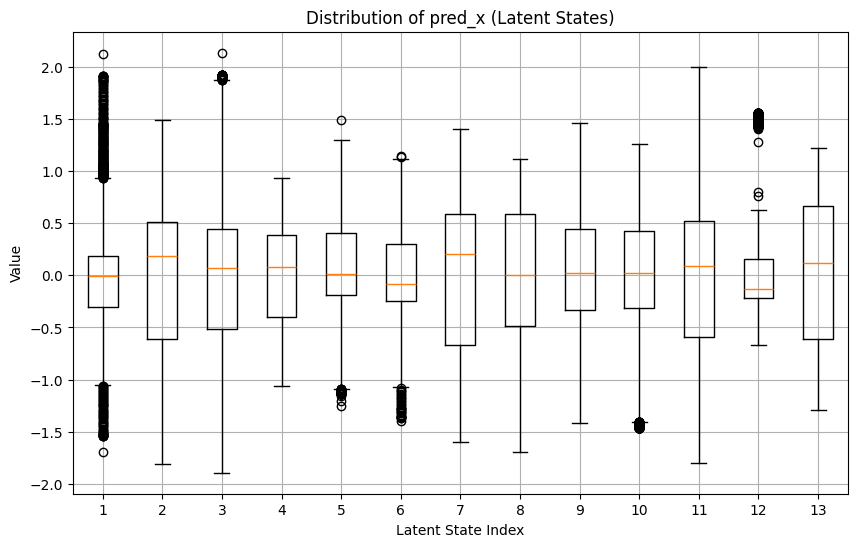

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(pred_x.T)
plt.title('Distribution of pred_x (Latent States)')
plt.xlabel('Latent State Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()